In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten
from tensorflow.keras.layers import MaxPooling2D, Dropout

from tensorflow.keras.utils import to_categorical

In [50]:
# df = pd.read_csv("train.csv")
# df_test = pd.read_csv("test.csv")

from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [51]:
# df.head()
# each image is of 28*28 pixels, label represent the number, eg label=4 then pixels represent number 4

In [52]:
# df.shape

In [53]:
# df['label'].value_counts()

In [54]:
# df.isnull().sum()

In [55]:
# no null are there

In [56]:
# data preprocessing

# X_train = df.drop(["label"],axis=1).values
# y_train = df["label"].values
# X_test = df_test.values
# y_test = df_test["label"].values


In [57]:
# df_test.head()

In [58]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [59]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [60]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [61]:
# ------------------------DATA READY---------------------------

In [62]:
# using perceptron, getting around 90% accuracy!!

In [63]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [64]:
perceptron.compile(optimizer="sgd" , loss="categorical_crossentropy", metrics=["accuracy"])

In [65]:
history_percep = perceptron.fit(X_train_img,y_train_cat,
                                epochs=5, batch_size=32,
                                validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8172 - loss: 0.7785 - val_accuracy: 0.8806 - val_loss: 0.4783
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8821 - loss: 0.4552 - val_accuracy: 0.8960 - val_loss: 0.4003
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8916 - loss: 0.4025 - val_accuracy: 0.9019 - val_loss: 0.3663
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8976 - loss: 0.3762 - val_accuracy: 0.9070 - val_loss: 0.3478
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9010 - loss: 0.3595 - val_accuracy: 0.9097 - val_loss: 0.3355


In [66]:
acc_percep = perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [67]:
acc_percep

0.9096999764442444

ANNs now

In [68]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])

In [69]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [70]:
history_ann = ann.fit(X_train_img, y_train_cat,epochs=5,batch_size=32, validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9320 - loss: 0.2340 - val_accuracy: 0.9578 - val_loss: 0.1298
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9686 - loss: 0.1020 - val_accuracy: 0.9735 - val_loss: 0.0851
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9778 - loss: 0.0706 - val_accuracy: 0.9696 - val_loss: 0.0985
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9826 - loss: 0.0548 - val_accuracy: 0.9788 - val_loss: 0.0705
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9869 - loss: 0.0414 - val_accuracy: 0.9770 - val_loss: 0.0783


In [71]:
ann_hist = ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]
ann_hist

0.9769999980926514

using ANNs accuracy is 97%

In [72]:
# Now CNNs

In [73]:
X_train_cnn = X_train.reshape(-1,28,28,1) # replace last 1 with 3 in case of RGB image (color channel)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [74]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [75]:
# cnn.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [76]:
hist_cnn = cnn.fit(X_train_cnn,y_train_cat,batch_size=32,epochs=5, validation_data=(X_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9385 - loss: 0.2021 - val_accuracy: 0.9861 - val_loss: 0.0422
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9785 - loss: 0.0743 - val_accuracy: 0.9889 - val_loss: 0.0324
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9835 - loss: 0.0539 - val_accuracy: 0.9902 - val_loss: 0.0295
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - accuracy: 0.9862 - loss: 0.0451 - val_accuracy: 0.9917 - val_loss: 0.0252
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9886 - loss: 0.0374 - val_accuracy: 0.9927 - val_loss: 0.0234


In [77]:
acc_cnn = cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn*100

99.26999807357788

In [78]:
def plot_hist(history, title):
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.plot(history.history["accuracy"], label="Train")
  plt.plot(history.history["val_accuracy"], label="Val")
  plt.title(f'{title} Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(history.history["loss"], label="Train")
  plt.plot(history.history["val_loss"], label="Val")
  plt.title(f'{title} Loss')
  plt.legend()
  plt.show()

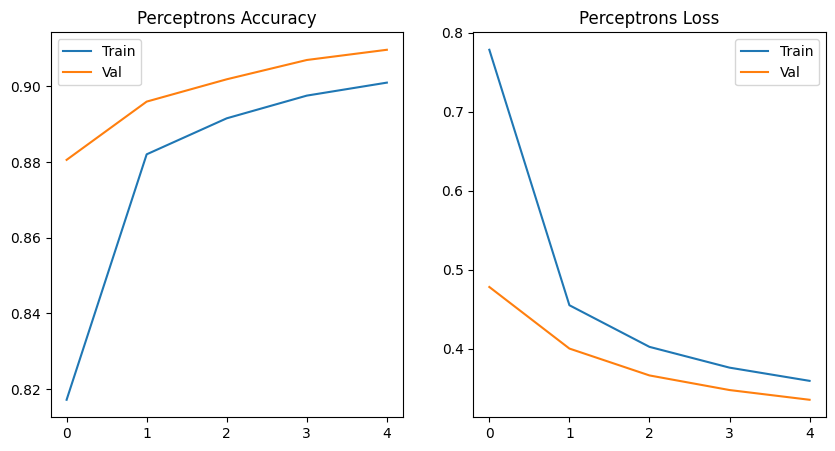

In [79]:
plot_hist(history_percep,"Perceptrons")

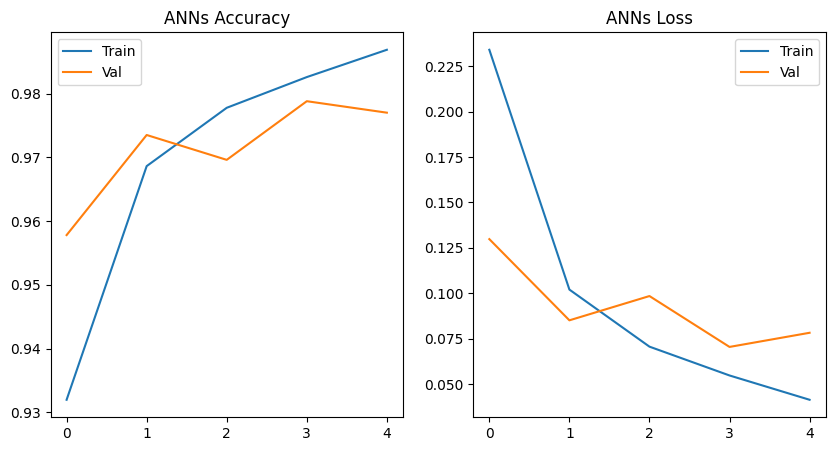

In [80]:
plot_hist(history_ann,"ANNs")

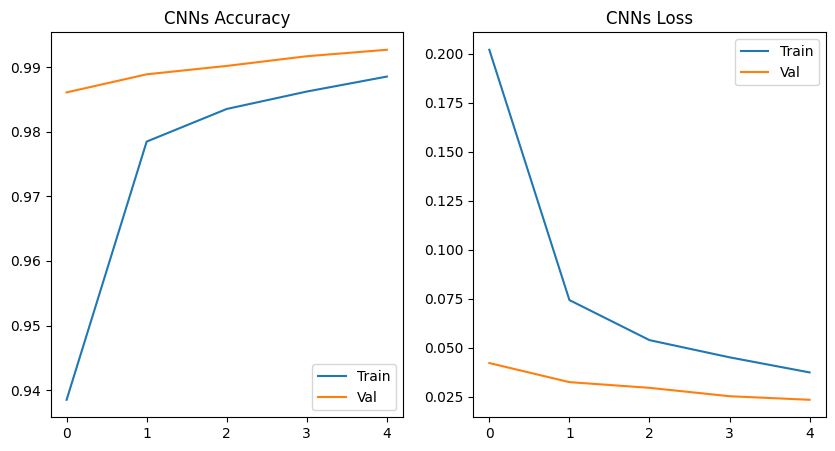

In [81]:
plot_hist(hist_cnn,"CNNs")

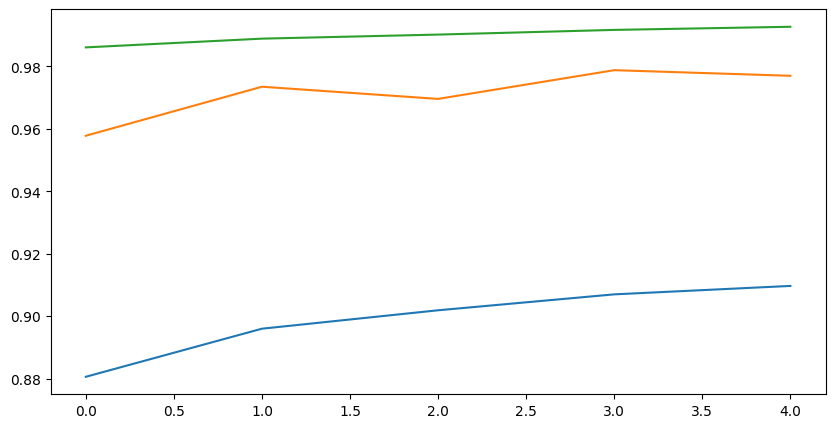

In [82]:
plt.figure(figsize=(10,5))
plt.plot(history_percep.history["val_accuracy"], label="Perceptron")
plt.plot(history_ann.history["val_accuracy"], label="ANn")
plt.plot(hist_cnn.history["val_accuracy"], label="CNN")
plt.title("Validation Accuracy comparision")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

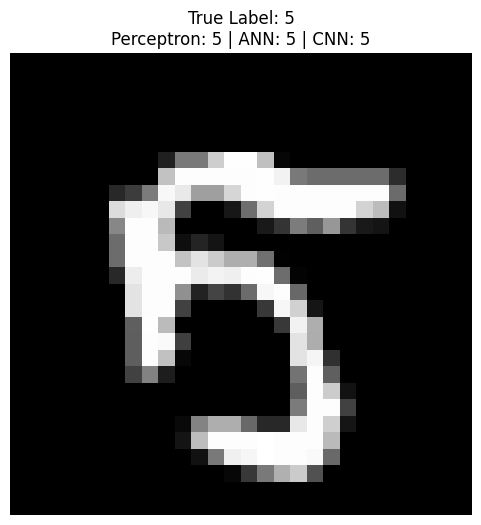

In [108]:
import matplotlib.pyplot as plt
import numpy as np

def compare_predictions(index=None):
    if index is None:
        index = np.random.randint(0, len(X_test))

    # Get original image and ground truth
    img = X_test[index]
    true_label = y_test[index]

    # Prepare inputs for each model
    # Perceptron and ANN expect (1, 28, 28)
    img_input = img.reshape(1, 28, 28)
    # CNN expects (1, 28, 28, 1)
    img_input_cnn = img.reshape(1, 28, 28, 1)

    # Get predictions
    pred_percep = np.argmax(perceptron.predict(img_input, verbose=0))
    pred_ann = np.argmax(ann.predict(img_input, verbose=0))
    pred_cnn = np.argmax(cnn.predict(img_input_cnn, verbose=0))

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"True Label: {true_label}\nPerceptron: {pred_percep} | ANN: {pred_ann} | CNN: {pred_cnn}")
    plt.axis('off')
    plt.show()

# Compare a random sample
compare_predictions()

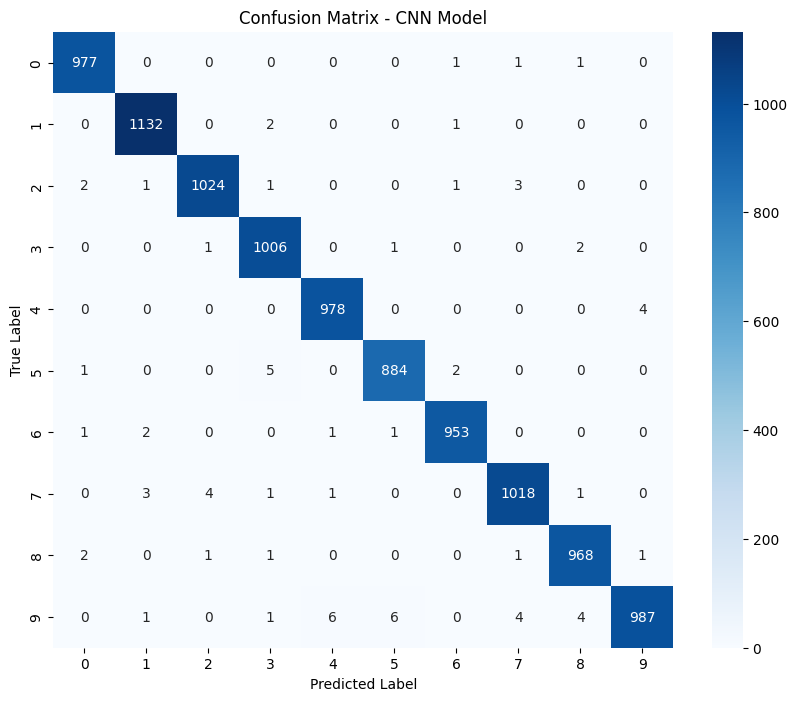

In [109]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get predictions for the entire test set
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn, verbose=0), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)

# Plotting using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - CNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [110]:
# Also printing the classification report for detailed metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

